In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import regularizers

In [2]:
df = pd.read_csv("Dataset/Training_set.csv")
df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [12]:
classlabel = df['label'].value_counts()

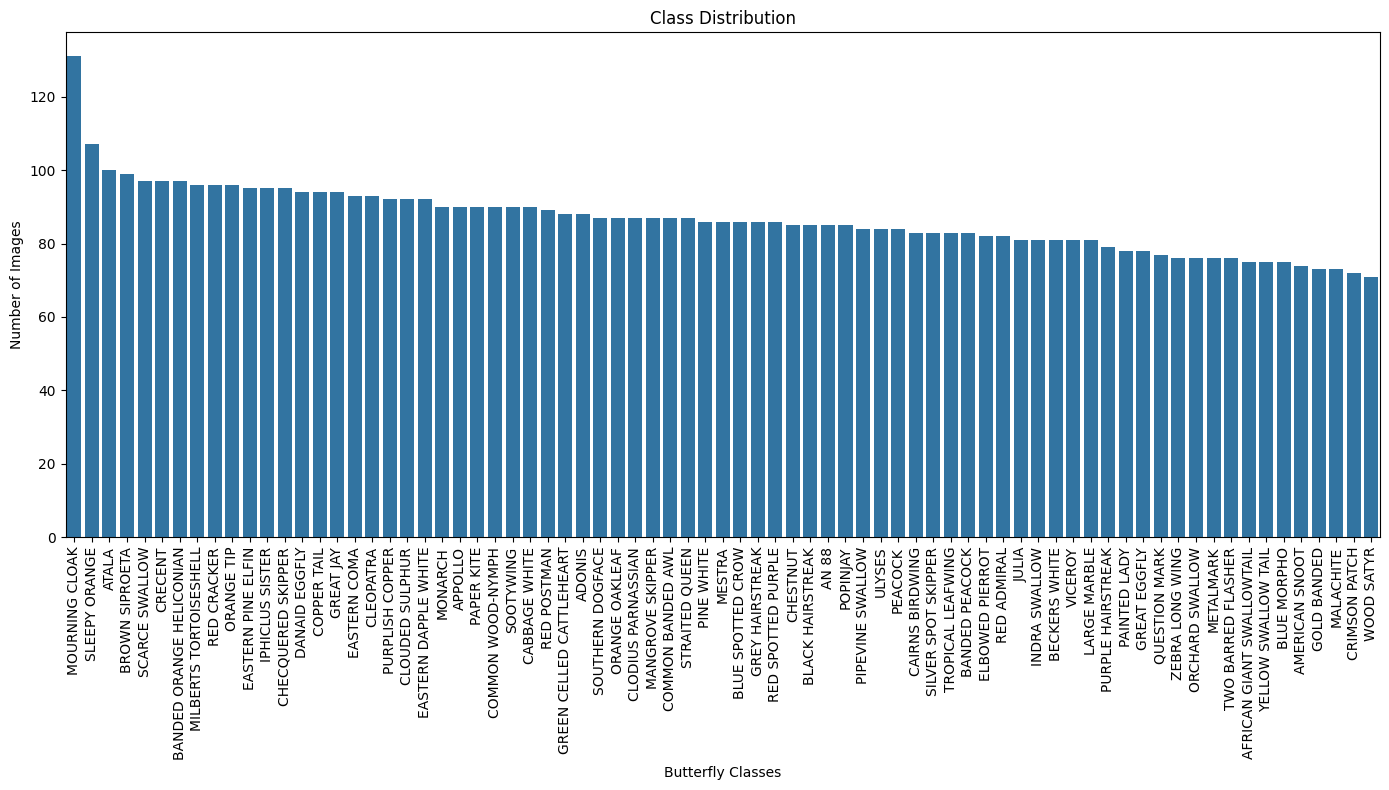

In [13]:
plt.figure(figsize=(14, 8))
sns.barplot(x=classlabel.index, y=classlabel.values)
plt.title('Class Distribution')
plt.xlabel('Butterfly Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
len(df)

6499

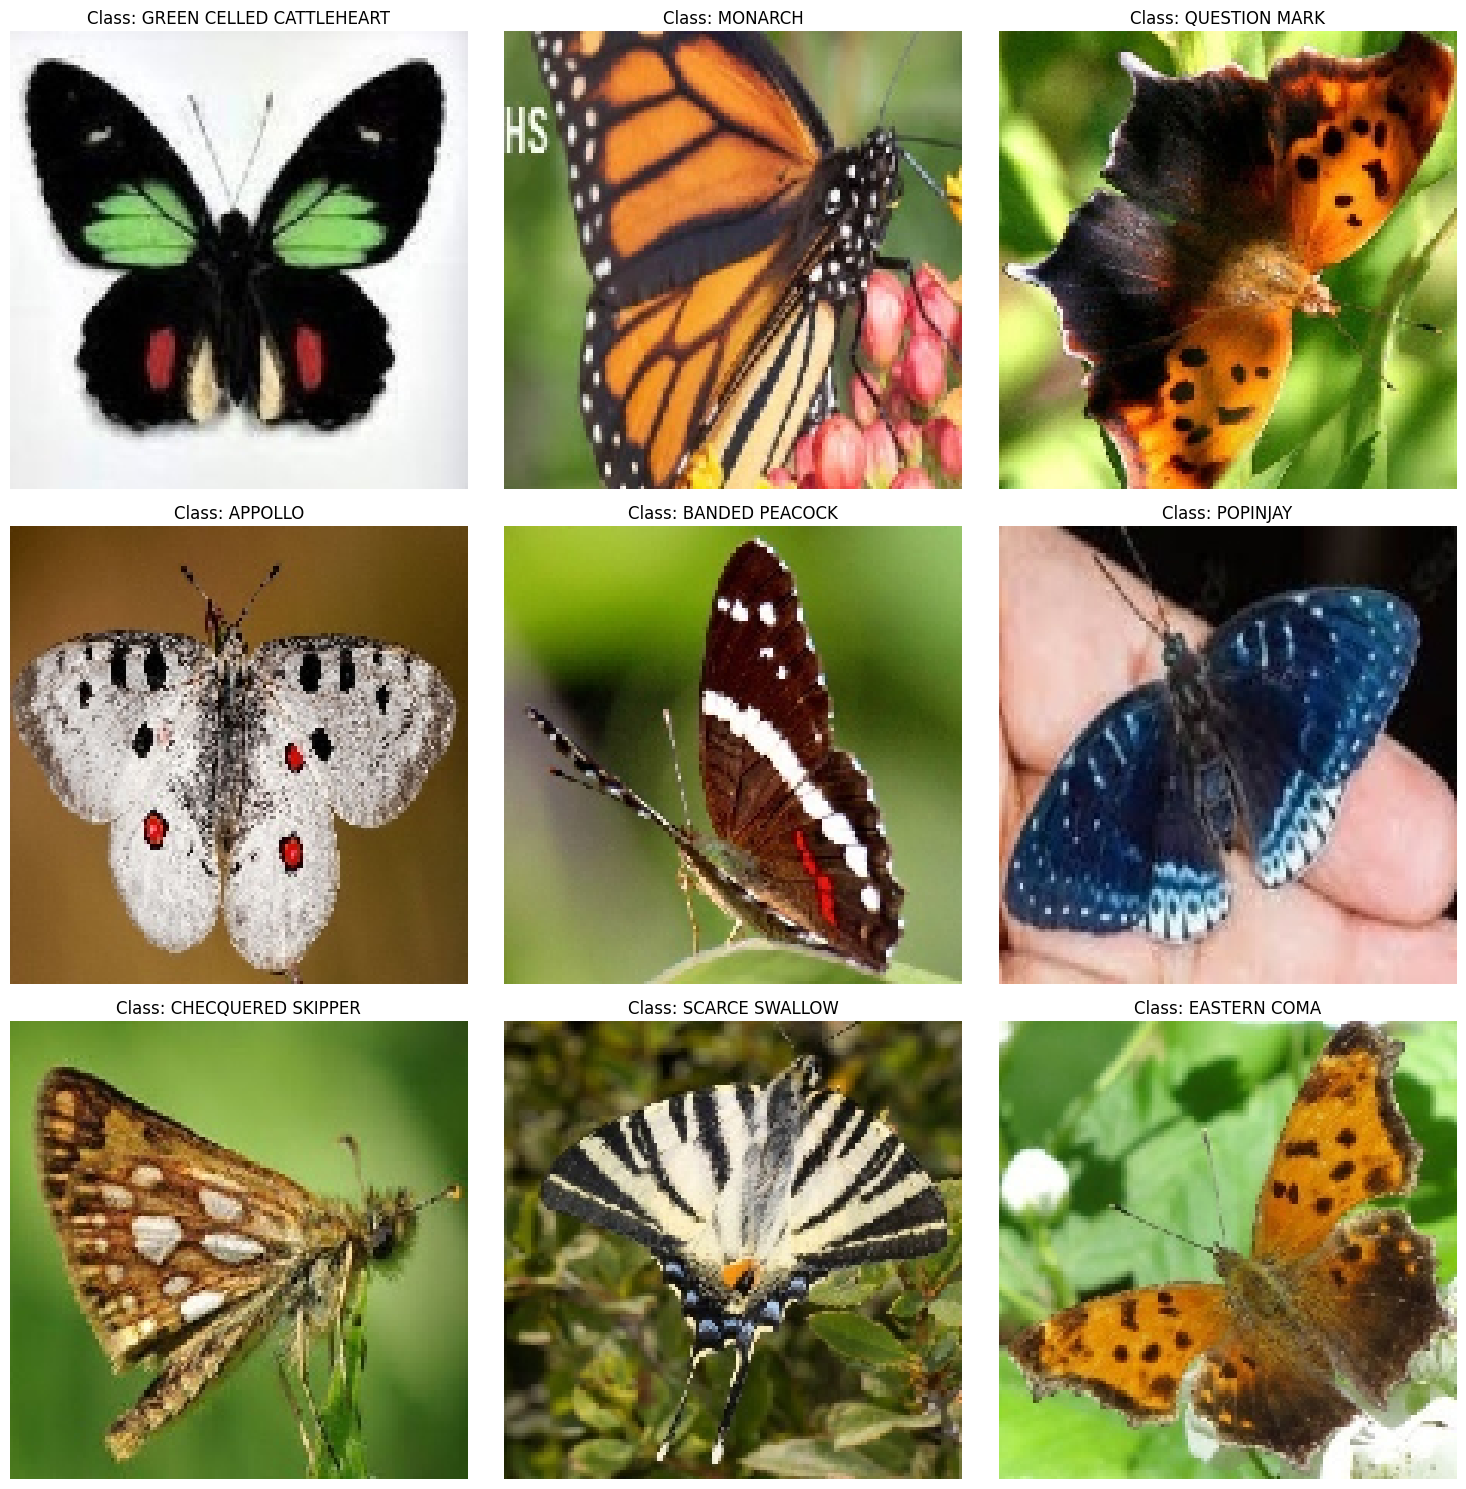

In [15]:
# Load CSV
df = pd.read_csv("Training_set.csv")

# Local image folder
image_dir = "dataset/train"

# Random samples
sample_images = df.sample(9, random_state=42)

# Plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, (index, row) in enumerate(sample_images.iterrows()):

    # Create full path
    img_path = os.path.join(image_dir, row['filename'])

    # Load image
    img = load_img(img_path, target_size=(150, 150))

    # Convert to array
    img_array = img_to_array(img) / 255.0

    # Display
    ax = axes[i // 3, i % 3]
    ax.imshow(img_array)
    ax.set_title(f"Class: {row['label']}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
img = load_img(img_path, target_size=(150, 150))

In [17]:
img_array = img_array / 255.0

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [22]:
test_df.shape

(1300, 3)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

# Convolution layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(150,150,3)))

# Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Second conv layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(len(le.classes_), activation='softmax'))

c:\Users\User\anaconda3\envs\mlb\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)